# Modeling and Simulation - Bike Share System
Introduction to Modeling and Simulation

**What is a Model?**

In the context of science and engineering, a model is a simplified representation of a real-world system. The goal of a model is to capture the essential features of the system in a way that allows us to predict its behavior. Models can be mathematical, physical, or computational.

For example, imagine we are trying to understand a bike share system in a city. A city might have a number of bike stations, each with a certain number of bikes. People can borrow bikes from any station and return them to any other station. Our task is to model this system in a simplified form to understand how well the system works and how to make it more efficient.

**What is a Simulation?**

A simulation is a process of using a model to study the behavior of a system over time. Simulations are often used when it's difficult or impossible to study the actual system directly. By simulating a system, we can ask "what if" questions and test how the system responds to different conditions.

<div style="display: flex;">
    <div>
        <img src="https://drive.google.com/uc?export=view&id=1jkKAp3Z1Dw23aX7rqFcamRJn18sZgnsi" alt="Description" width="150" style="float: right; margin-left: 20px;">
    </div>
</div>

In this lab, we will use Python to build a simple simulation of a bike share system and study how it behaves under different conditions.

**Defining the System**

Imagine a city that has set up a bike-sharing program. There are multiple stations scattered across the city, each station equipped with bikes and docks.

Stations are the places where the bikes are stored. Each station has a limited number of bikes and a limited number of docks (parking spots for bikes). Some stations might be busier than others, and the number of bikes can vary from station to station at different times of the day.

Bikes are what people use for transport. We don't need to track each individual bike (for simplicity), but we do care about how many bikes are available at each station.

Trips represent the movement of bikes. A trip occurs when a person picks up a bike from one station and drops it off at another. The goal of the system is to ensure that bikes are available when people need them, and that there are enough empty docks when people return the bikes.


---



The Challenge:
Even in a simple bike-sharing system, you still need to manage the following:

* Bike Availability: A station can't provide a bike if it's empty.
* Dock Availability: A station can't accept a returned bike if all docks are full.
* Trips: As bikes move from one station to another, we track where they are picked up and dropped off.

### Basic Python Modelling

In [2]:
# Model your bike system using basic python below
max_capacity_A = 15 
max_capacity_B = 10
max_capacity_C = 8

station_A_bikes = 6
station_B_bikes = 10
station_C_bikes = 4

def move_bike(source_station, target_station, max_capacity_target):
    if source_station <= 0:
        print("Not enough bikes in source station.")
    if target_station >= max_capacity_target:
        print("Target station is at full capacity.")
    else:
        source_station -= 1
        target_station += 1
        print("New source number of bikes: ", source_station)
        print("New target number of bikes: ", target_station)

# Example usage:
print("Before moving bikes:")
print("Station A bikes:", station_A_bikes)
print("Station B bikes:", station_B_bikes)
move_bike(station_A_bikes, station_B_bikes, max_capacity_B)
print("After moving bikes:")
print("Station A bikes:", station_A_bikes)  
print("Station B bikes:", station_B_bikes)

# mai mergeea facut cu dictionare sau trb sa dai return la nr nou de bikes si 

Before moving bikes:
Station A bikes: 6
Station B bikes: 10
Target station is at full capacity.
After moving bikes:
Station A bikes: 6
Station B bikes: 10


### Python Classes Introduction

In [3]:
# Defining a Class: A class is defined using the class keyword
class MyClass:
    pass  # This creates an empty class

**Constructor** (__init__ method): The __init__ method is a special function that gets called when an object (instance of the class) is created. It initializes the attributes of the object.

In [4]:
class Person:
    def __init__(self, name, age):
        self.name = name  # Attribute
        self.age = age    # Attribute

# self refers to the current instance of the class.
# Attributes like name and age are created and initialized in the constructor.

Creating an Object (Instance): To create an instance (object) of a class, you call the class as if it were a function:

In [5]:
person1 = Person("Alice", 30)  # Creates a Person object with name "Alice" and age 30
print(person1.name)  # Output: Alice

Alice


Methods: Methods are functions defined inside a class that operate on the instance’s data (attributes).

In [6]:
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def greet(self):
        print(f"Hello, my name is {self.name} and I'm {self.age} years old.")

person1 = Person("Alice", 30)
person1.greet()  # Output: Hello, my name is Alice and I'm 30 years old.

Hello, my name is Alice and I'm 30 years old.


Let's write our bikesharing system using Python classes now, allowing us to generalize to any number of stations.

In [7]:
# Write the system using Python Classes
class Station:
    def __init__(self, id, current_bikes, max_capacity):
        self.id = id
        self.current_bikes = current_bikes
        self.max_capacity = max_capacity

station_A_bikes = Station("A", 6, 10)
station_B_bikes = Station("B", 10, 15)
station_C_bikes = Station("C", 4, 8)

def move_bike(source_station, target_station):
    if source_station.current_bikes <= 0:
        print("Not enough bikes in source station.")
    elif target_station.current_bikes >= target_station.max_capacity:
        print("Target station is at full capacity.")
    else:
        source_station.current_bikes -= 1
        target_station.current_bikes += 1
        # print(f"Moved bike from Station {source_station.id} to Station {target_station.id}.")
        # print(f"New number of bikes in Station {source_station.id}: {source_station.current_bikes}")
        # print(f"New number of bikes in Station {target_station.id}: {target_station.current_bikes}")

# Example usage:
print("Before moving bikes:")
print("Station A bikes:", station_A_bikes.current_bikes)
print("Station B bikes:", station_B_bikes.current_bikes)
move_bike(station_A_bikes, station_B_bikes)
print("After moving bikes:")
print("Station A bikes:", station_A_bikes.current_bikes)
print("Station B bikes:", station_B_bikes.current_bikes)

Before moving bikes:
Station A bikes: 6
Station B bikes: 10
After moving bikes:
Station A bikes: 5
Station B bikes: 11


### Introducing Probabilities and Time


In this extended version of the bike-sharing system, we introduce probabilities and time to simulate trips between stations over a set period. We aim to model the likelihood of bike movement between stations at each minute. We will use the following probabilities:

* 0.3 probability: On average, there is a 30% chance per minute that a bike will be taken from the UPT station to the Center station.
* 0.5 probability: On average, there is a 50% chance per minute that a bike will be taken from the Center station to the UPT station.

In [8]:
# Extend implementation to simulate a couple of times what happens with the system in a 30 minutes period
# Write code below
import random

def flip(p):
    if random.random() < p:
        return True
    else:
        return False

print(flip(0.5))

station_A_bikes = Station("A", 6, 10)
station_B_bikes = Station("B", 10, 15)
station_C_bikes = Station("C", 4, 8)

probability_move_A_to_B = 0.6
probability_move_A_to_C = 0.5
probability_move_B_to_A = 0.3
probability_move_B_to_C = 0.2
probability_move_C_to_A = 0.2
probability_move_C_to_B = 0.7

print("Initial state:")
print("Station A bikes:", station_A_bikes.current_bikes)
print("Station B bikes:", station_B_bikes.current_bikes)
print("Station C bikes:", station_C_bikes.current_bikes)

for i in range(30):
    if(flip(probability_move_A_to_B)):
        move_bike(station_A_bikes, station_B_bikes)
    if(flip(probability_move_A_to_C)):
        move_bike(station_A_bikes, station_C_bikes)
    if(flip(probability_move_B_to_A)):
        move_bike(station_B_bikes, station_A_bikes)
    if(flip(probability_move_B_to_C)):
        move_bike(station_B_bikes, station_C_bikes)
    if(flip(probability_move_C_to_A)):  
        move_bike(station_C_bikes, station_A_bikes)
    if(flip(probability_move_C_to_B)):
        move_bike(station_C_bikes, station_B_bikes)
    print(f"After minute {i+1}:")
    print("Station A bikes:", station_A_bikes.current_bikes)
    print("Station B bikes:", station_B_bikes.current_bikes)
    print("Station C bikes:", station_C_bikes.current_bikes)


True
Initial state:
Station A bikes: 6
Station B bikes: 10
Station C bikes: 4
After minute 1:
Station A bikes: 5
Station B bikes: 11
Station C bikes: 4
After minute 2:
Station A bikes: 4
Station B bikes: 12
Station C bikes: 4
After minute 3:
Station A bikes: 5
Station B bikes: 12
Station C bikes: 3
After minute 4:
Station A bikes: 4
Station B bikes: 14
Station C bikes: 2
After minute 5:
Station A bikes: 5
Station B bikes: 15
Station C bikes: 0
Target station is at full capacity.
Not enough bikes in source station.
After minute 6:
Station A bikes: 5
Station B bikes: 15
Station C bikes: 0
Target station is at full capacity.
Target station is at full capacity.
After minute 7:
Station A bikes: 4
Station B bikes: 15
Station C bikes: 1
Target station is at full capacity.
After minute 8:
Station A bikes: 4
Station B bikes: 15
Station C bikes: 1
Target station is at full capacity.
Target station is at full capacity.
After minute 9:
Station A bikes: 3
Station B bikes: 15
Station C bikes: 2
Targ

### Save logs and plot data for analysis

To perform some analysis and visualize the results of the bike-sharing simulation, we can record the number of bikes at each station over time and then plot this data using the matplotlib library. This will help us understand how the bike availability at each station changes over time based on the probabilities.

False
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Not enough bikes in source station.
Not enough bikes in source station.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Not enough bikes in source station.
Not enough bikes in source station.
Target station is at full capacity.
Target station is at full capacity.
Not enough bikes in source station.
Target station is at full capacity.
Not enough bikes in source station.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
[(6, 10, 4), (5, 11, 4), (4, 12, 4), (4, 13, 3), (3, 14, 3), (4, 15, 1), (5, 15, 0), (5, 15, 0), (5, 15, 0), (6, 14, 0), (5, 15, 0

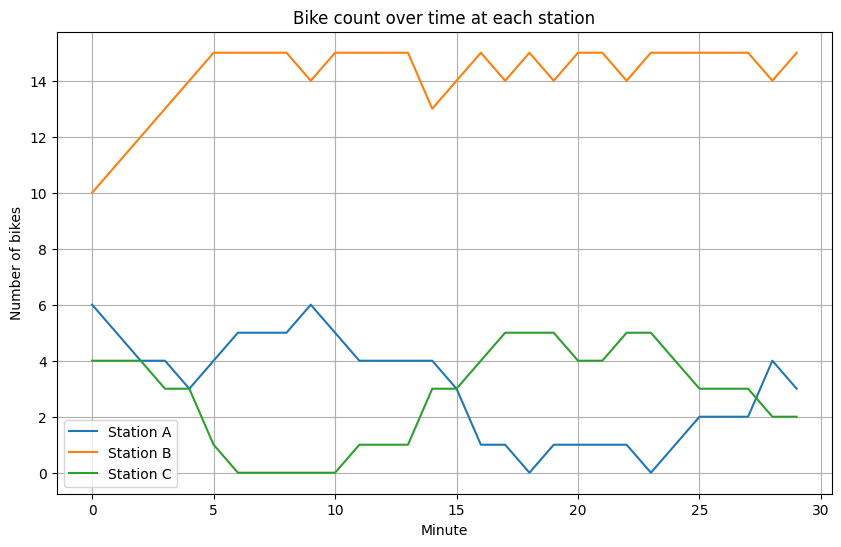

In [9]:
# Save history at each minute and add plotting of said history
# Write code below

import random
import matplotlib.pyplot as plt
import numpy as np

def flip(p):
    if random.random() < p:
        return True
    else:
        return False

print(flip(0.5))

def move_bike(source_station, target_station):
    if source_station.current_bikes <= 0:
        print("Not enough bikes in source station.")
    elif target_station.current_bikes >= target_station.max_capacity:
        print("Target station is at full capacity.")
    else:
        source_station.current_bikes -= 1
        target_station.current_bikes += 1
        # print(f"Moved bike from Station {source_station.id} to Station {target_station.id}.")
        # print(f"New number of bikes in Station {source_station.id}: {source_station.current_bikes}")
        # print(f"New number of bikes in Station {target_station.id}: {target_station.current_bikes}")

probability_move_A_to_B = 0.6
probability_move_A_to_C = 0.5
probability_move_B_to_A = 0.3
probability_move_B_to_C = 0.2
probability_move_C_to_A = 0.2
probability_move_C_to_B = 0.7

station_A_bikes = Station("A", 6, 10)
station_B_bikes = Station("B", 10, 15)
station_C_bikes = Station("C", 4, 8)

bike_system_states = []


for i in range(30):
    if flip(probability_move_A_to_B):
        move_bike(station_A_bikes, station_B_bikes)
    if flip(probability_move_A_to_C):
        move_bike(station_A_bikes, station_C_bikes)
    if flip(probability_move_B_to_A):
        move_bike(station_B_bikes, station_A_bikes)
    if flip(probability_move_B_to_C):
        move_bike(station_B_bikes, station_C_bikes)
    if flip(probability_move_C_to_A):  
        move_bike(station_C_bikes, station_A_bikes)
    if flip(probability_move_C_to_B):
        move_bike(station_C_bikes, station_B_bikes)

    bike_system_states.append((
        station_A_bikes.current_bikes, 
        station_B_bikes.current_bikes, 
        station_C_bikes.current_bikes
    ))

print(bike_system_states)


x = np.arange(30)
y = np.array(bike_system_states)

plt.figure(figsize=(10, 6))
plt.plot(x, y[:, 0], label="Station A")
plt.plot(x, y[:, 1], label="Station B")
plt.plot(x, y[:, 2], label="Station C")
plt.xlabel("Minute")
plt.ylabel("Number of bikes")
plt.title("Bike count over time at each station")
plt.legend()
plt.grid()
plt.show()


### Analyze events - Unhappy customers

Every time a rider can not get his bike because of the station being empty or being unable to return his bike to target station because of it being full, he will leave unhappy. We can track the number of times this occurs by simulating our system multiple times. We can vary the system variable and check average number of dissatisfied customers per hour for each of our setups. E.g. we leave more bikes in circulation, less bikes in circulation, we increase the number of max bike slots per station, etc.

True
Target station is at full capacity.
Target station is at full capacity.
Not enough bikes in source station.
Target station is at full capacity.
Not enough bikes in source station.
Target station is at full capacity.
Target station is at full capacity.
Not enough bikes in source station.
Not enough bikes in source station.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Target station is at full capacity.
Not enough bikes in source station.
Target station is at full capacity.
Not enough bikes in source station.
Target station is at fu

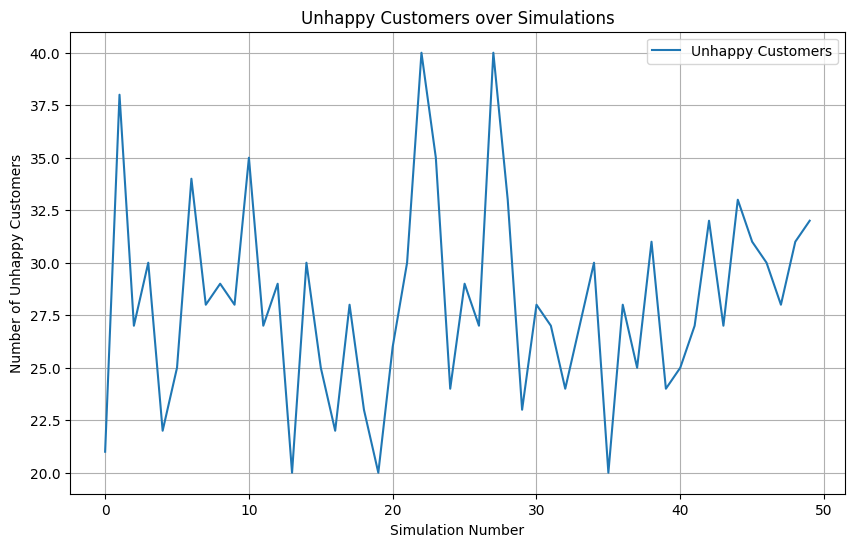

In [12]:
# Write code to check average number of dissatisfied customer events over a sample size of 50 simulations, 30 minutes each.
# Vary any of the system variables and analyze the impact

import random
import matplotlib.pyplot as plt
import numpy as np

def flip(p):
    if random.random() < p:
        return True
    else:
        return False

print(flip(0.5))

def move_bike(source_station, target_station):
    if source_station.current_bikes <= 0:
        print("Not enough bikes in source station.")
    elif target_station.current_bikes >= target_station.max_capacity:
        print("Target station is at full capacity.")
    else:
        source_station.current_bikes -= 1
        target_station.current_bikes += 1
        # print(f"Moved bike from Station {source_station.id} to Station {target_station.id}.")
        # print(f"New number of bikes in Station {source_station.id}: {source_station.current_bikes}")
        # print(f"New number of bikes in Station {target_station.id}: {target_station.current_bikes}")

probability_move_A_to_B = 0.6
probability_move_A_to_C = 0.5
probability_move_B_to_A = 0.3
probability_move_B_to_C = 0.2
probability_move_C_to_A = 0.2
probability_move_C_to_B = 0.7

station_A_bikes = Station("A", 6, 10)
station_B_bikes = Station("B", 10, 15)
station_C_bikes = Station("C", 4, 8)

bike_system_states = []
unhappy_states = []

# pt partea de 30 de minute
def unhappy_sim():
    unhappy = 0
    for i in range(30):
        if flip(probability_move_A_to_B):
            if station_A_bikes.current_bikes == 0 or station_B_bikes.current_bikes == station_B_bikes.max_capacity:
                unhappy += 1    
            move_bike(station_A_bikes, station_B_bikes)
        if flip(probability_move_A_to_C):
            if station_A_bikes.current_bikes == 0 or station_C_bikes.current_bikes == station_C_bikes.max_capacity:
                unhappy += 1    
            move_bike(station_A_bikes, station_C_bikes)
        if flip(probability_move_B_to_A):
            if station_B_bikes.current_bikes == 0 or station_A_bikes.current_bikes == station_A_bikes.max_capacity:
                unhappy += 1    
            move_bike(station_B_bikes, station_A_bikes)
        if flip(probability_move_B_to_C):
            if station_B_bikes.current_bikes == 0 or station_C_bikes.current_bikes == station_C_bikes.max_capacity:
                unhappy += 1
            move_bike(station_B_bikes, station_C_bikes)
        if flip(probability_move_C_to_A):  
            if station_C_bikes.current_bikes == 0 or station_A_bikes.current_bikes == station_A_bikes.max_capacity:
                unhappy += 1
            move_bike(station_C_bikes, station_A_bikes)
        if flip(probability_move_C_to_B):
            if station_C_bikes.current_bikes == 0 or station_B_bikes.current_bikes == station_B_bikes.max_capacity:
                unhappy += 1
            move_bike(station_C_bikes, station_B_bikes)

        bike_system_states.append((
            station_A_bikes.current_bikes, 
            station_B_bikes.current_bikes, 
            station_C_bikes.current_bikes
        ))

    unhappy_states.append(unhappy)

def run_simulations(num_simulations):
    total_unhappy = 0
    for i in range(num_simulations):
        unhappy_sim()
        total_unhappy += unhappy_states[-1]
    
run_simulations(50)

x = np.arange(50)
y = np.array(unhappy_states)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label="Unhappy Customers")
plt.xlabel("Simulation Number")
plt.ylabel("Number of Unhappy Customers")
plt.title("Unhappy Customers over Simulations")
plt.legend()
plt.grid()
plt.show()